In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/falkodz/TER.git /content/TER
!pip install transformers emoji==0.6.0 -q

import os, shutil
os.makedirs('/content/TER/data', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')
print("Done ✓")

Mounted at /content/drive
Cloning into '/content/TER'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 80 (delta 37), reused 60 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.57 MiB | 17.72 MiB/s, done.
Resolving deltas: 100% (37/37), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Done ✓


In [2]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# Vérifier GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['Tweet', 'sentiment', 'Date'],
                 low_memory=False)

df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df = df.dropna(subset=['Tweet', 'sentiment', 'Date'])
df = df[df['Tweet'].str.strip() != '']

label2id = {'positive': 0, 'neutral': 1, 'negative': 2}
id2label = {0: 'positive', 1: 'neutral', 2: 'negative'}
df['label'] = df['sentiment'].map(label2id)
df['month'] = df['Date'].dt.to_period('M')

print(f"Shape: {df.shape}")
print(df['month'].value_counts().sort_index())

Device: cuda
Shape: (476164, 5)
month
2022-11        77
2022-12     80872
2023-01    105555
2023-02    128459
2023-03    132763
2023-04     28438
Freq: M, Name: count, dtype: int64


In [3]:
# Charger le tokenizer
tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base', use_fast=False)

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, max_length=max_length,
            padding='max_length', return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

def evaluate_bertweet(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].numpy())
    return f1_score(all_labels, all_preds, average='macro')

print("Tokenizer loaded ✓")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

Tokenizer loaded ✓


In [5]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import time

folds = [
    {'train': ['2022-12'],                                   'test': '2023-01'},
    {'train': ['2022-12', '2023-01'],                        'test': '2023-02'},
    {'train': ['2022-12', '2023-01', '2023-02'],             'test': '2023-03'},
    {'train': ['2022-12', '2023-01', '2023-02', '2023-03'],  'test': '2023-04'},
]

bertweet_results = []

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*50}")
    print(f"Fold {fold_idx+1}/4 — Train: {fold['train']} → Test: {fold['test']}")
    print('='*50)

    train_df = df[df['month'].astype(str).isin(fold['train'])]
    test_df  = df[df['month'].astype(str) == fold['test']]

    train_sample = train_df.sample(min(15000, len(train_df)), random_state=42)
    test_sample  = test_df.sample(min(5000,  len(test_df)),  random_state=42)

    print(f"Train size: {len(train_sample)} | Test size: {len(test_sample)}")

    # Tokenize
    print("Tokenizing...")
    train_dataset = TweetDataset(train_sample['Tweet'], train_sample['label'], tokenizer)
    test_dataset  = TweetDataset(test_sample['Tweet'],  test_sample['label'],  tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        'vinai/bertweet-base', num_labels=3,
        id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
    )
    model = model.to(device)

    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    total_steps = len(train_loader) * 2
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1*total_steps),
        num_training_steps=total_steps
    )

    # Training 2 epochs
    for epoch in range(2):
        model.train()
        total_loss = 0
        t0 = time.time()
        for step, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += outputs.loss.item()
        print(f"  Epoch {epoch+1} — Loss: {total_loss/len(train_loader):.4f} ({time.time()-t0:.0f}s)")

    f1 = evaluate_bertweet(model, test_loader, device)
    bertweet_results.append({
        'train': ' + '.join(fold['train']),
        'test': fold['test'],
        'f1_macro': round(f1, 4)
    })
    print(f"Test F1 macro: {f1:.4f}")

print("\nDone ✓")
print(bertweet_results)


Fold 1/4 — Train: ['2022-12'] → Test: 2023-01
Train size: 15000 | Test size: 5000
Tokenizing...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 — Loss: 0.7402 (320s)
  Epoch 2 — Loss: 0.4159 (320s)
Test F1 macro: 0.8264

Fold 4/4 — Train: ['2022-12', '2023-01', '2023-02', '2023-03'] → Test: 2023-04
Train size: 15000 | Test size: 5000
Tokenizing...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 — Loss: 0.7024 (316s)
  Epoch 2 — Loss: 0.3817 (320s)
Test F1 macro: 0.8265

Done ✓
[{'train': '2022-12', 'test': '2023-01', 'f1_macro': 0.8158}, {'train': '2022-12 + 2023-01', 'test': '2023-02', 'f1_macro': 0.842}, {'train': '2022-12 + 2023-01 + 2023-02', 'test': '2023-03', 'f1_macro': 0.8264}, {'train': '2022-12 + 2023-01 + 2023-02 + 2023-03', 'test': '2023-04', 'f1_macro': 0.8265}]


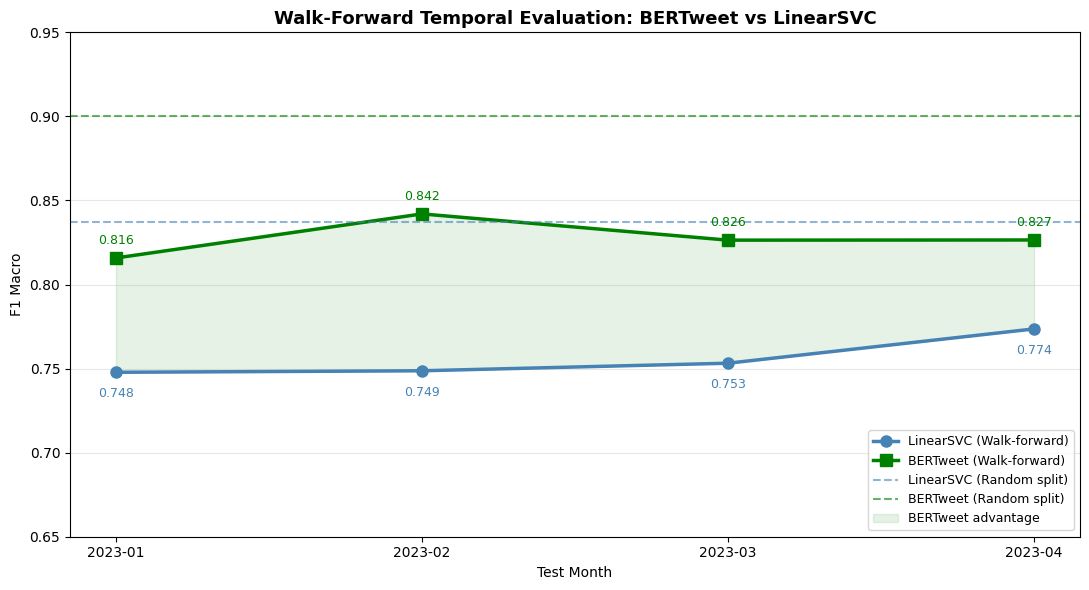

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

linsvc_results = [0.7478, 0.7487, 0.7532, 0.7736]
bertweet_results_f1 = [r['f1_macro'] for r in bertweet_results]
test_months = ['2023-01', '2023-02', '2023-03', '2023-04']

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(test_months, linsvc_results, 'o-', color='steelblue',
        linewidth=2.5, markersize=8, label='LinearSVC (Walk-forward)')
ax.plot(test_months, bertweet_results_f1, 's-', color='green',
        linewidth=2.5, markersize=8, label='BERTweet (Walk-forward)')

ax.axhline(0.8371, color='steelblue', linestyle='--', linewidth=1.5,
           alpha=0.6, label='LinearSVC (Random split)')
ax.axhline(0.9004, color='green', linestyle='--', linewidth=1.5,
           alpha=0.6, label='BERTweet (Random split)')

for i, (ls, bt) in enumerate(zip(linsvc_results, bertweet_results_f1)):
    ax.annotate(f"{ls:.3f}", xy=(test_months[i], ls),
                xytext=(0, -18), textcoords='offset points',
                ha='center', fontsize=9, color='steelblue')
    ax.annotate(f"{bt:.3f}", xy=(test_months[i], bt),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='green')

ax.fill_between(test_months, linsvc_results, bertweet_results_f1,
                alpha=0.1, color='green', label='BERTweet advantage')

ax.set_title('Walk-Forward Temporal Evaluation: BERTweet vs LinearSVC', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Month')
ax.set_ylabel('F1 Macro')
ax.set_ylim(0.65, 0.95)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/TER/figures/14_bertweet_vs_linsvc_walkforward.png', dpi=150)
plt.show()

In [4]:
import subprocess
from getpass import getpass
import shutil, os

os.makedirs('/content/TER/notebooks', exist_ok=True)
os.makedirs('/content/TER/figures', exist_ok=True)

shutil.copy('/content/drive/MyDrive/Colab Notebooks/09_bertweet_walkforward.ipynb',
            '/content/TER/notebooks/09_bertweet_walkforward.ipynb')

subprocess.run(['git', 'config', 'user.email', 'ton@email.com'], cwd='/content/TER')
subprocess.run(['git', 'config', 'user.name', 'falkodz'], cwd='/content/TER')
subprocess.run(['git', 'add', '.'], cwd='/content/TER')
r = subprocess.run(['git', 'commit', '-m', 'Add BERTweet walk-forward evaluation (F1=0.82-0.84)'],
                   cwd='/content/TER', capture_output=True, text=True)
print(r.stdout, r.stderr)

token = getpass("Token : ")
result = subprocess.run(
    ['git', 'push', f'https://{TOKEN_REMOVED}@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout, result.stderr)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/09_bertweet_walkforward.ipynb'